# 05 · Q5: SNAP enrollment and food shelf use

> *"Do the two move together, or does one replace the other? What happens to food shelf activity when the SNAP benefits change? Does the relationship differ across locations?"*

| Part | Question |
|---|---|
| **A** | Together or replace? (over time + across counties) |
| **B** | What happens when SNAP benefits change? (Apr 2023 cut; 2025–26 enrollment drop) |
| **C** | Does it differ across locations? |
| **D** | Message for lawmakers + slide-ready charts |

**Plan and decisions:** `docs/q5_plan.md` · **In-depth explainer:** `docs/05_q5_snap_foodshelf.md`

**SNAP source:** MN DHS Reports and Forecasts Division, *"SNAP and State-Funded Food: Minnesota Cases, Recipients, and Payments"* (`Data/SNAP_20XX_RAW.pdf`). County agency × month, Jan 2022 – Mar 2026. Publication lag ≈ 3 weeks (final annual version the following January).
🚨 Never re-download the 2026 SNAP PDF: a newer copy may contain August 2026 data → disqualification.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "Data" / "processed"

snap_raw = pd.read_csv(PROCESSED / "snap_2022_2026_clean.csv")
fs = pd.read_csv(PROCESSED / "foodshelf_county_month.csv", dtype={"fips": str}, parse_dates=["month"])
mmg = pd.read_csv(PROCESSED / "mmg_mn_county_2022_2024.csv", dtype={"fips": str})
pov = pd.read_csv(PROCESSED / "poverty_2022_2024_clean.csv", dtype={"county_geoid": str}).rename(columns={"county_geoid": "fips"})
rural_share = pd.read_csv(PROCESSED / "rural_share_2020_clean.csv", dtype={"fips": str})
site = pd.read_csv(PROCESSED / "foodshelf_site_month.csv", dtype={"fips": str}, parse_dates=["month"])
FIG_DIR = ROOT / "outputs" / "q5"
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["visits", "pounds", "individuals"]
print("SNAP:", snap_raw.shape, "| food shelf:", fs.shape, "| MMG:", mmg.shape, "| poverty:", pov.shape)

SNAP: (4437, 7) | food shelf: (4785, 12) | MMG: (261, 21) | poverty: (261, 16)


## Step 1: Prepare the data

### 1a. SNAP: dates, benefit per person, and agency → county

- **What:** turn `year` + `month` (e.g. `January`) into a real date; compute **benefit per person** = `snap_expenditure / snap_people`; label each agency as `single` (one county), `combined` (MNPrairie, WPHS) or `tribal`, and attach FIPS to the 82 single-county agencies.
- **Why:** dates let us line SNAP up with food shelf months; benefit per person separates *how much each person gets* from *how many people are enrolled*; FIPS is how we join to every other file.
- **Outcome:** one SNAP table, 87 agencies × 51 months, with `agency_type` and `fips` (blank for combined/tribal).
- **Why not split combined agencies by population:** that would invent county numbers the state never reported (same rule as the Q1 notebook).

In [2]:
COMBINED = {"MNPRAIRIE": ["Dodge", "Steele", "Waseca"], "WPHS": ["Grant", "Pope"]}
TRIBAL = ["MILLE-LACS-BAND TRIBE", "WHITE EARTH NATION", "RED LAKE INDIAN RESV"]
# counties whose SNAP is partly counted under a tribal agency (Q1 notebook rule)
TRIBAL_OVERLAP = ["Mahnomen", "Becker", "Clearwater", "Beltrami", "Mille Lacs", "Pine", "Aitkin"]

snap = snap_raw.copy()
snap["month"] = pd.to_datetime(snap["year"].astype(str) + "-" + snap["month"], format="%Y-%B")
snap["benefit_per_person"] = snap["snap_expenditure"] / snap["snap_people"]
snap["agency_type"] = np.select(
    [snap["county"].isin(COMBINED), snap["county"].isin(TRIBAL)], ["combined", "tribal"], default="single")

name_to_fips = dict(zip(mmg["county"].str.upper(), mmg["fips"]))
snap["fips"] = np.where(snap["agency_type"] == "single", snap["county"].map(name_to_fips), None)
assert snap.loc[snap["agency_type"] == "single", "fips"].notna().all(), "a single-county agency didn't match"
assert not snap.duplicated(["county", "month"]).any()

print("months:", snap["month"].min().date(), "->", snap["month"].max().date(), "|", snap["month"].nunique(), "months")
snap.groupby("agency_type").agg(agencies=("county", "nunique"), avg_people=("snap_people", lambda s: round(s.sum() / snap["month"].nunique())))

months: 2022-01-01 -> 2026-03-01 | 51 months


,agencies,avg_people
agency_type,,
combined,2,6884
single,82,426570
tribal,3,5847


### 1b. Statewide monthly table (Parts A and B)

- **What:** add up SNAP (all 87 agencies, including tribal and combined) and food shelf activity (all counties) per month, for the months both datasets cover.
- **Why:** statewide totals avoid the agency-vs-county problem entirely: every SNAP recipient in Minnesota is counted exactly once.
- **Outcome:** one row per month, Jan 2022 – Mar 2026 (51 rows).
- **Why not only the 82 matched counties:** the statewide story should include everyone, including tribal nations.

In [3]:
snap_state = snap.groupby("month").agg(snap_people=("snap_people", "sum"), snap_cases=("snap_cases", "sum"),
                                       snap_dollars=("snap_expenditure", "sum"))
snap_state["benefit_per_person"] = snap_state["snap_dollars"] / snap_state["snap_people"]

fs_state = fs.groupby("month")[METRICS].sum()
state = snap_state.join(fs_state, how="inner")
assert len(state) == 51 and state.index.min() == pd.Timestamp("2022-01-01") and state.index.max() == pd.Timestamp("2026-03-01")
print("statewide table:", state.shape, "|", state.index.min().date(), "->", state.index.max().date())
state.round(1).iloc[[0, 14, 15, 16, -1]]

statewide table: (51, 7) | 2022-01-01 -> 2026-03-01


,snap_people,snap_cases,snap_dollars,benefit_per_person,visits,pounds,individuals
month,,,,,,,
2022-01-01,425042,217618,96306389.0,226.6,124388.0,8650033.3,355540.0
2023-03-01,466994,238071,121377753.6,259.9,190705.0,11291031.7,593228.0
2023-04-01,440333,225626,70592625.6,160.3,191473.0,10668544.9,591137.0
2023-05-01,444678,228411,69805063.1,157.0,203291.0,11622129.9,614019.0
2026-03-01,421422,226055,71310693.7,169.2,277840.0,13591602.7,862114.0


### 1c. County table (Parts A and C)

- **What:** for the **82 single-county agencies**, join SNAP to food shelf activity by FIPS + month, and attach population, poverty and **rural share** (% of residents living rurally, Census 2020).
- **Why:** county comparisons need SNAP and food shelf numbers for the same place.
- **Outcome:** county × month table. Counties in combined agencies (Dodge, Steele, Waseca, Grant, Pope) aren't in it; the 7 tribal-overlap counties are kept but flagged `tribal_overlap` so county SNAP rates can exclude them.
- **Why keep tribal-overlap counties at all:** their food shelf numbers are fine; only their county SNAP count is incomplete. Each analysis decides whether to drop them.
- Population and poverty come from the ACS 5-year file (latest = 2024 window). Wilkin has no food shelf, so its food shelf metrics are blank.

In [4]:
pov_latest = pov[pov["year"] == 2024][["fips", "population", "poverty_count", "poverty_rate"]]
rural = mmg[mmg["year"] == 2024][["fips", "county", "rural"]]

county = (snap[snap["agency_type"] == "single"][["fips", "month", "snap_people", "snap_expenditure", "benefit_per_person"]]
          .merge(fs[["fips", "month"] + METRICS + ["n_sites"]], on=["fips", "month"], how="inner", validate="one_to_one")
          .merge(rural, on="fips", how="left", validate="many_to_one")
          .merge(pov_latest, on="fips", how="left", validate="many_to_one")
          .merge(rural_share[["fips", "pct_rural_2020", "rural_band"]], on="fips", how="left", validate="many_to_one"))
county["tribal_overlap"] = county["county"].isin(TRIBAL_OVERLAP)
assert county["population"].notna().all() and county["pct_rural_2020"].notna().all()

print("county table:", county.shape, "|", county["fips"].nunique(), "counties x", county["month"].nunique(), "months")
print("tribal-overlap counties flagged:", sorted(county.loc[county["tribal_overlap"], "county"].unique()))
print("counties with no food shelf data:", sorted(county.loc[county["n_sites"] == 0, "county"].unique()))

county table: (4182, 17) | 82 counties x 51 months
tribal-overlap counties flagged: ['Aitkin', 'Becker', 'Beltrami', 'Clearwater', 'Mahnomen', 'Mille Lacs', 'Pine']
counties with no food shelf data: ['Wilkin']


---
# Part A: Do SNAP and food shelves move together, or does one replace the other?

**Two possible answers:**
- **"Replace" (substitutes):** when SNAP goes **down**, food shelf use goes **up** (and vice versa). Food shelves fill the gap SNAP leaves.
- **"Together" (complements):** both go **up and down together**, because the same struggling families use both.

We check it **two ways**:
1. **A1. Over time:** month by month across Minnesota, when SNAP enrollment changed, which way did food shelf use move?
2. **A2. Across counties:** do counties with **more** people on SNAP have **more** or **fewer** food shelf visits per resident?

## A1. Over time (statewide)

- **What:** (1) a chart of SNAP enrollment and food shelf visits, both scaled so **Jan 2022 = 100** (so they fit on one chart); (2) the **Spearman correlation** between their **year-over-year changes** (each month vs the same month a year earlier).
- **Why year-over-year changes, not the raw numbers:** visits climbed every year while SNAP stayed flat, so raw numbers would mostly reflect that trend. YoY changes ask *"when SNAP grew faster or slower than usual, did visits too?"* and remove seasons.
- **How to read the correlation:** around **+1** = move together; around **−1** = move opposite (replace); around **0** = no clear link.
- **Why not month-to-month changes:** both rise and fall with the seasons, which would create a fake "together" link.

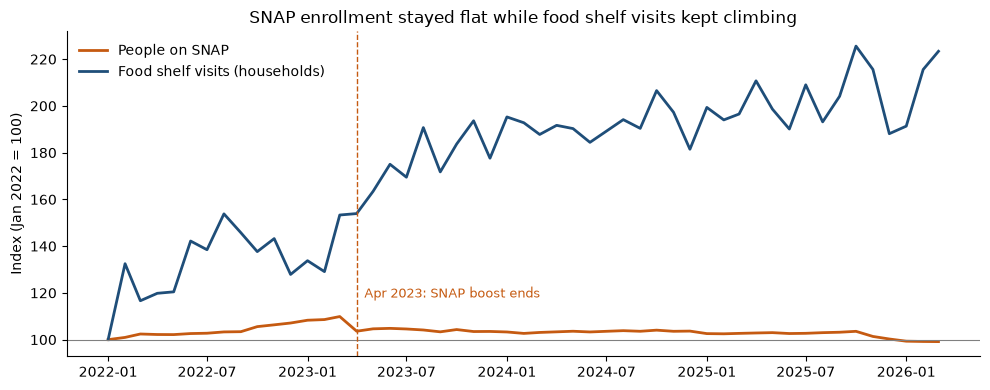

months compared: 39 (Jan 2023 - Mar 2026)
Mar 2022 -> Mar 2026: SNAP people -3%, visits +92%, individuals +99%


,food shelf metric,Spearman rho with SNAP-enrollment change,p-value
0,visits,-0.06,0.73
1,pounds,0.15,0.38
2,individuals,0.07,0.69


In [5]:
from scipy.stats import spearmanr

idx = state[["snap_people", "visits", "individuals", "pounds"]].div(state[["snap_people", "visits", "individuals", "pounds"]].iloc[0]).mul(100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(idx.index, idx["snap_people"], color="#c55a11", lw=2, label="People on SNAP")
ax.plot(idx.index, idx["visits"], color="#1f4e79", lw=2, label="Food shelf visits (households)")
ax.axhline(100, color="grey", lw=0.8)
ax.axvline(pd.Timestamp("2023-04-01"), color="#c55a11", ls="--", lw=1)
ax.text(pd.Timestamp("2023-04-15"), 118, "Apr 2023: SNAP boost ends", color="#c55a11", fontsize=9)
ax.set_ylabel("Index (Jan 2022 = 100)")
ax.set_title("SNAP enrollment stayed flat while food shelf visits kept climbing")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "q5_a1_snap_vs_visits_index.png", dpi=200)
plt.show()

chg = state[["snap_people", "visits", "individuals", "pounds"]].pct_change(12, fill_method=None).mul(100).dropna()
a1 = pd.DataFrame([{"food shelf metric": m, "Spearman rho with SNAP-enrollment change": spearmanr(chg["snap_people"], chg[m])[0],
                    "p-value": spearmanr(chg["snap_people"], chg[m])[1]} for m in METRICS]).round(2)
print(f"months compared: {len(chg)} ({chg.index.min():%b %Y} - {chg.index.max():%b %Y})")
# compare the same month (March) so seasons don't distort the change
m22, m26 = state.loc["2022-03-01"], state.loc["2026-03-01"]
print(f"Mar 2022 -> Mar 2026: SNAP people {m26['snap_people'] / m22['snap_people'] - 1:+.0%}, "
      f"visits {m26['visits'] / m22['visits'] - 1:+.0%}, individuals {m26['individuals'] / m22['individuals'] - 1:+.0%}")
a1

### Reading A1

- **Over the whole period, SNAP and food shelves went their separate ways:** comparing March 2022 with March 2026 (same month, so seasons don't distort it), SNAP enrollment **fell about 3%**, while food shelf visits **rose about 90%**. Food shelf growth clearly wasn't driven by SNAP *enrollment* going up or down.
- **The month-by-month link is about zero** for all three metrics (rho between about −0.1 and +0.15, none distinguishable from chance). When SNAP grew faster or slower than usual, food shelf use didn't reliably follow, in either direction.
- The one big SNAP change, the **April 2023 benefit cut**, is a **benefit-size** change, not an enrollment change, which is why Part B studies it separately.

## A2. Across counties

- **What:** for the 74 matchable counties (excluding tribal-overlap and combined-office counties), average 2023–2024 monthly numbers and compare:
  - **SNAP reach** = people on SNAP ÷ people in poverty (how well SNAP reaches the poor; above 1 is possible because SNAP's income limit is above the poverty line)
  - **SNAP per 1,000 residents**
  - **Food shelf visits per 1,000 residents**
- **Why per resident / per poor person:** removes county size (Hennepin would otherwise top everything).
- **How to read:** positive rho = counties with more SNAP also have more food shelf use (**together**); negative = **replace**; around 0 = no link.
- **Why not include tribal-overlap counties:** their county SNAP counts miss residents served by tribal SNAP offices, which would make their SNAP reach look falsely low.

counties: 74


,"compared with visits per 1,000",Spearman rho,p-value
0,snap_reach,0.10,0.40
1,snap_per_1000,0.12,0.31
2,poverty_rate,0.09,0.43


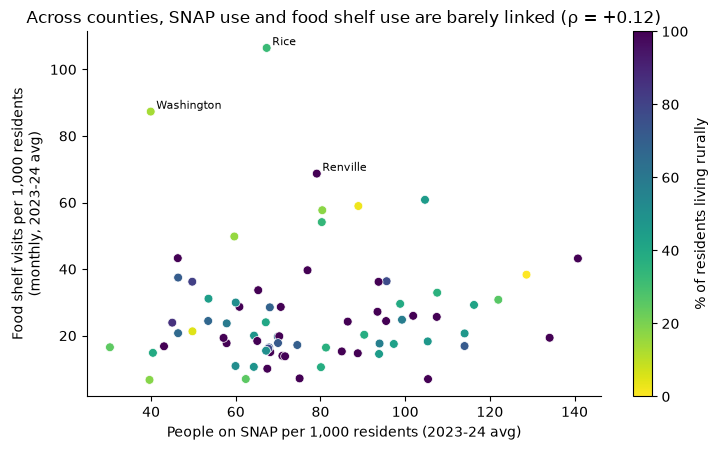

In [6]:
pov_23_24 = pov[pov["year"].isin([2023, 2024])].groupby("fips")[["population", "poverty_count"]].mean()
in_window = (county["month"] >= "2023-01-01") & (county["month"] <= "2024-12-01")
cty = (county[in_window & ~county["tribal_overlap"]]
       .groupby(["fips", "county"]).agg(snap_people=("snap_people", "mean"), visits=("visits", "mean"), pct_rural_2020=("pct_rural_2020", "first"))
       .reset_index().merge(pov_23_24, on="fips", validate="one_to_one"))
cty = cty[cty["visits"] > 0]
cty["snap_reach"] = cty["snap_people"] / cty["poverty_count"]
cty["snap_per_1000"] = cty["snap_people"] / cty["population"] * 1000
cty["visits_per_1000"] = cty["visits"] / cty["population"] * 1000
cty["poverty_rate"] = cty["poverty_count"] / cty["population"] * 100

a2 = pd.DataFrame([{"compared with visits per 1,000": x, "Spearman rho": spearmanr(cty[x], cty["visits_per_1000"])[0],
                    "p-value": spearmanr(cty[x], cty["visits_per_1000"])[1]}
                   for x in ["snap_reach", "snap_per_1000", "poverty_rate"]]).round(2)
print("counties:", len(cty))
display(a2)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
sc = ax.scatter(cty["snap_per_1000"], cty["visits_per_1000"], c=cty["pct_rural_2020"], cmap="viridis_r", s=40, edgecolor="white", linewidth=0.5)
for _, r in cty.nlargest(3, "visits_per_1000").iterrows():
    ax.annotate(r["county"], (r["snap_per_1000"], r["visits_per_1000"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("People on SNAP per 1,000 residents (2023-24 avg)")
ax.set_ylabel("Food shelf visits per 1,000 residents\n(monthly, 2023-24 avg)")
ax.set_title(f"Across counties, SNAP use and food shelf use are barely linked (ρ = {a2.iloc[1, 1]:+.2f})")
plt.colorbar(sc, label="% of residents living rurally")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "q5_a2_county_snap_vs_visits.png", dpi=200)
plt.show()

### Reading A2

- Counties with more people on SNAP have **slightly** more food shelf visits per resident (rho ≈ +0.1), but the link is **weak and not distinguishable from chance** (p ≈ 0.3).
- The same is true for poverty itself: poorer counties don't clearly have more food shelf use per resident. That matches the Q1 finding that food shelf use per resident doesn't track need well.
- So across counties, SNAP and food shelf use **don't replace each other** (we'd see a negative link), and they **only weakly go together**.

## Part A: summary

**Neither a clear "together" nor a clear "replace".**
- **Over time:** SNAP enrollment stayed flat or fell slightly (Mar 2022 → Mar 2026 ≈ −3%) while food shelf visits rose about 90%, and their month-to-month changes aren't linked. Food shelf demand grew for reasons **beyond SNAP enrollment**.
- **Across counties:** places with more SNAP use have only slightly more food shelf use.
- **Best reading:** SNAP and food shelves serve **overlapping but different needs**. Most food shelf growth since 2022 came from something other than changes in SNAP enrollment. The one SNAP change that *does* line up with food shelf demand is the **benefit cut** of April 2023 (Part B): *how much* SNAP gives matters more than *how many* people get it.

---
# Part B: What happens to food shelf activity when SNAP changes?

**Two SNAP changes in our data:**

| Event | When (payment month) | What changed |
|---|---|---|
| **1. COVID emergency boost ends** | **April 2023** | benefit per person **≈ $260 → $160**, and enrollment −5.7% the same month |
| **2. Enrollment falls** | **Nov 2025 → Mar 2026** | people on SNAP ≈ 440k → 421k (−4%) |

### How we measure it: year-over-year (YoY) change

Food shelf visits have seasons (January low, spring/fall high), so comparing *this month with last month* mixes the SNAP effect with the season. Instead we compare **each month with the same month one year earlier**: *"May 2023 vs. May 2022: +36%"*. Same season → the season cancels out.

**The trick that makes this work for April 2023:** look at which *two years* each YoY number compares:

| Window | This month | Same month last year | What the YoY growth contains |
|---|---|---|---|
| **Jan–Mar 2023** | boost | boost | normal growth only (**baseline**) |
| **Apr 2023 – Mar 2024** | after cut | boost | normal growth **+ effect of the cut** |
| **Apr 2024 – Mar 2025** | after cut | after cut | normal growth only (effect has dropped out) |

👉 If the cut pushed people to food shelves, YoY growth should be **higher in the middle window** than in the windows on either side.

## B1. Statewide year-over-year growth, month by month

- **What:** compute YoY % change for visits, pounds, individuals (and SNAP enrollment and benefit per person) for every month from Jan 2023 (the first month with a year-earlier comparison) to Jul 2026.
- **Why:** this is the basic picture everything else summarizes.
- **Outcome:** table + chart (saved to `outputs/q5/`).
- **Why not compare raw monthly totals:** seasons would swamp the effect (e.g. May is always busier than March).

In [7]:
fs_all = fs.groupby("month")[METRICS].sum()          # food shelf to Jul 2026
yoy = fs_all.pct_change(12, fill_method=None).mul(100).add_suffix("_yoy")
yoy = yoy.join(snap_state[["snap_people", "benefit_per_person"]].pct_change(12, fill_method=None).mul(100).add_suffix("_yoy"))
yoy = yoy.loc["2023-01-01":].round(1)
yoy.head(15)

,visits_yoy,pounds_yoy,individuals_yoy,snap_people_yoy,benefit_per_person_yoy
month,,,,,
2023-01-01,33.8,17.0,42.4,8.3,12.5
2023-02-01,-2.6,22.9,42.2,7.6,10.7
2023-03-01,31.4,21.3,37.0,7.3,12.4
2023-04-01,28.5,10.7,25.2,1.4,-30.3
2023-05-01,35.7,17.2,27.5,2.4,-32.2
2023-06-01,23.1,16.9,30.8,2.2,-32.0
2023-07-01,22.4,18.0,32.1,1.8,-32.3
2023-08-01,24.0,20.8,35.4,0.8,-32.4
2023-09-01,17.9,16.5,28.5,-0.1,-29.5


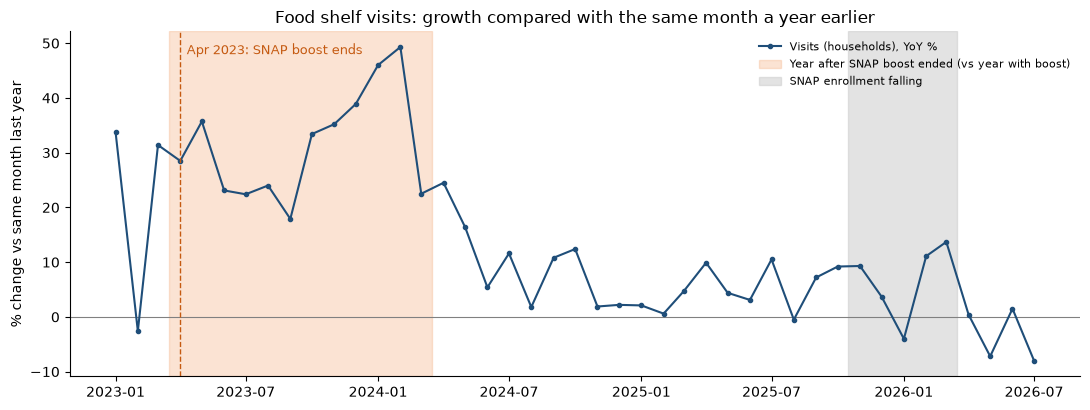

In [8]:
def window(d):
    if d <= pd.Timestamp("2023-03-01"): return "1. Jan-Mar 2023: boost vs boost"
    if d <= pd.Timestamp("2024-03-01"): return "2. Apr 2023-Mar 2024: after cut vs boost"
    if d <= pd.Timestamp("2025-03-01"): return "3. Apr 2024-Mar 2025: after vs after"
    if d <= pd.Timestamp("2025-10-01"): return "4. Apr-Oct 2025: before SNAP drop"
    if d <= pd.Timestamp("2026-03-01"): return "5. Nov 2025-Mar 2026: SNAP enrollment falling"
    return "6. Apr-Jul 2026: no SNAP data yet"
yoy["window"] = yoy.index.map(window)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axhline(0, color="grey", lw=0.8)
ax.plot(yoy.index, yoy["visits_yoy"], marker="o", ms=3, color="#1f4e79", label="Visits (households), YoY %")
ax.axvspan(pd.Timestamp("2023-03-16"), pd.Timestamp("2024-03-16"), color="#f4b183", alpha=0.35, label="Year after SNAP boost ended (vs year with boost)")
ax.axvspan(pd.Timestamp("2025-10-16"), pd.Timestamp("2026-03-16"), color="#c9c9c9", alpha=0.5, label="SNAP enrollment falling")
ax.axvline(pd.Timestamp("2023-04-01"), color="#c55a11", ls="--", lw=1)
ax.text(pd.Timestamp("2023-04-10"), ax.get_ylim()[1] * 0.92, "Apr 2023: SNAP boost ends", color="#c55a11", fontsize=9)
ax.set_ylabel("% change vs same month last year")
ax.set_title("Food shelf visits: growth compared with the same month a year earlier")
ax.legend(loc="upper right", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "q5_b1_visits_yoy.png", dpi=200)
plt.show()

## B2. Average growth in each window (the main result)

- **What:** average the monthly YoY numbers within each window, for all three metrics.
- **Why:** one table that answers *"did growth jump after the cut?"*; averaging smooths out single odd months (e.g. Feb 2023).
- **Outcome:** table below.
- **Why not a regression with a trend line:** growth was **not** a straight line. It was very fast in 2022–2023 and then flattened. A straight trend would be wrong, and the "after" switch would soak up that bend and look like a SNAP effect. The window comparison only compares like with like.

In [9]:
windows = (yoy.groupby("window")[["visits_yoy", "pounds_yoy", "individuals_yoy", "snap_people_yoy", "benefit_per_person_yoy"]]
             .mean().round(1))
windows["months"] = yoy.groupby("window").size()
windows

,visits_yoy,pounds_yoy,individuals_yoy,snap_people_yoy,benefit_per_person_yoy,months
window,,,,,,
1. Jan-Mar 2023: boost vs boost,20.9,20.4,40.5,7.7,11.9,3
2. Apr 2023-Mar 2024: after cut vs boost,31.4,18.9,36.7,-1.3,-32.9,12
3. Apr 2024-Mar 2025: after vs after,7.9,5.8,8.9,-0.4,3.5,12
4. Apr-Oct 2025: before SNAP drop,6.3,-3.7,0.5,-0.6,-0.3,7
5. Nov 2025-Mar 2026: SNAP enrollment falling,6.8,3.4,6.1,-3.0,1.9,5
6. Apr-Jul 2026: no SNAP data yet,-3.3,1.1,0.7,NaN,NaN,4


### Reading B2

**Visits (households): growth jumped in the year after the cut, then fell back.**

| Window | Visits YoY |
|---|---|
| Jan–Mar 2023 (boost vs boost) | **+21%** |
| Apr 2023 – Mar 2024 (after cut vs boost) | **+31%** |
| Apr 2024 – Mar 2025 (after vs after) | **+8%** |

That **hump in the middle window is the pattern we'd expect if the cut pushed households to food shelves**: about **10 percentage points of extra growth** on top of the baseline.

**But the other two metrics don't show the hump:**
- **Individuals:** +41% → +37% → +9%. Already growing very fast before the cut; no extra jump.
- **Pounds:** +20% → +19% → +6%. No extra jump either. More household trips, but **not more food**, which suggests each visit got less (food shelves can only give what they have).

**Timing:** the extra growth wasn't immediate. Visits YoY stayed around +18–36% from April to September 2023, then climbed to **+33% to +49% from October 2023 to February 2024**. A delayed response fits households using up savings or other help first, but other things also changed in that period (see limitations).

## B3. Robustness: is it just more food shelves reporting?

- **What:** redo visits YoY using only **matched sites**: food shelves that reported in *both* the month and the same month a year earlier.
- **Why:** if new food shelves joined (or stopped reporting), totals could rise or fall for reasons that have nothing to do with SNAP. Matched sites compare the same places both years.
- **Outcome:** matched-site YoY per window, next to the all-sites version.
- **Why not per-site averages:** sites differ hugely in size; summing matched sites keeps big and small sites in proportion.

In [10]:
reported = site[(site["site_group"] != "meal") & site["visits"].notna()]
wide = reported.pivot_table(index="site_id", columns="month", values="visits")
rows = []
for m in wide.columns:
    prev = m - pd.DateOffset(years=1)
    if prev in wide.columns:
        both = wide[[m, prev]].dropna()
        rows.append({"month": m, "matched_sites": len(both), "matched_visits_yoy": (both[m].sum() / both[prev].sum() - 1) * 100})
matched = pd.DataFrame(rows).set_index("month")
matched["window"] = matched.index.map(window)

robust = pd.DataFrame({
    "all sites: visits YoY": yoy.groupby("window")["visits_yoy"].mean(),
    "matched sites: visits YoY": matched.groupby("window")["matched_visits_yoy"].mean(),
    "avg matched sites": matched.groupby("window")["matched_sites"].mean(),
}).round(1)
robust

,all sites: visits YoY,matched sites: visits YoY,avg matched sites
window,,,
1. Jan-Mar 2023: boost vs boost,20.9,11.1,406.0
2. Apr 2023-Mar 2024: after cut vs boost,31.4,31.0,434.4
3. Apr 2024-Mar 2025: after vs after,7.9,10.5,439.2
4. Apr-Oct 2025: before SNAP drop,6.3,8.1,437.9
5. Nov 2025-Mar 2026: SNAP enrollment falling,6.8,6.0,432.2
6. Apr-Jul 2026: no SNAP data yet,-3.3,-3.8,422.5


### Reading B3

**The hump survives when we only compare the same food shelves both years:** matched-site visits growth is **+11% → +31% → +11%**. The middle window stands out even more clearly (about **20 points** above both neighbours). So the jump isn't caused by food shelves joining or leaving the data.

The baseline (Jan–Mar 2023) is only **3 months** long, because our data starts in Jan 2022 and YoY needs a year earlier. That's the weakest part of this comparison; the "after vs after" window (12 months) is a sturdier reference.

## B4. Event 2: SNAP enrollment falling (Nov 2025 – Mar 2026)

From the B2 table:

| Window | SNAP people YoY | Visits YoY | Individuals YoY | Pounds YoY |
|---|---|---|---|---|
| Apr–Oct 2025 (before the drop) | −0.6% | +6.3% | +0.5% | −3.7% |
| Nov 2025 – Mar 2026 (enrollment falling) | **−3.0%** | +6.8% | **+6.1%** | +3.4% |

- **Individuals** and **pounds** grew faster once enrollment started falling; **visits** barely changed.
- This is **weak evidence**: only 5 months, the drop is small (−3% to −4%), and early 2026 also had other shocks The Food Group itself mentions (food and gas prices, immigration enforcement in the metro). Feb–Mar 2026 were record months, but so was the whole period.
- We **can't follow it further**: SNAP data ends in March 2026 (publication lag). Visits YoY turned negative from April 2026, but we have no SNAP numbers for those months to compare.

## Part B: summary

1. **When the SNAP boost ended (Apr 2023), food shelf visits grew about 10 points faster than before** (+21% → +31% YoY), and about 20 points faster than the same food shelves' growth before and after. Growth fell back to about +8–11% once both years were "after the cut".
2. **The response built up over months**, peaking October 2023 – February 2024, rather than appearing the month the benefit dropped.
3. **Only visits show it.** Individuals and pounds didn't jump: more household trips, not more people counted or more food handed out.
4. **The 2025–26 enrollment drop shows at most a small rise** (individuals +0.5% → +6% YoY). It's too recent and too mixed with other events to call.

**Limitations to say out loud:**
- The cut hit **all of Minnesota at once**, so there's no untouched comparison group. Part C (counties that lost more vs less) helps with this.
- Other changes happened around the same time: grocery prices were still high (Q4), and SNAP enrollment itself fell 5.7% in April 2023.
- The pre-cut baseline is only 3 months long.
- We describe **association with timing**, not proof of cause.

---
# Part C: Did counties that lost more SNAP money see a bigger jump in visits?

**Why this test:** the April 2023 cut hit **all of Minnesota at once**, so Part B can't rule out that something *else* happening statewide caused the jump. But the cut didn't hit every county **equally**: counties where more people were on SNAP lost more money per resident.

**The logic (like a medicine dose):** if the cut pushed people to food shelves, then **bigger loss → bigger jump in visits**. If every county jumped about the same no matter how much it lost, the cut probably isn't the main driver of the *differences* between counties.

## C1. How much SNAP money each county lost, per resident

- **What:** for each county, average monthly SNAP dollars in **Jan–Mar 2023** (boost still on) minus **Apr–Jun 2023** (boost gone), divided by the county's population (ACS 2023).
- **Why per resident:** Hennepin loses millions just because it's big; per resident makes counties comparable.
- **Outcome:** one number per county, e.g. "$12.80 less SNAP per resident per month".
- **Why not use a longer "after" period:** October brings a yearly cost-of-living increase, which would mix in a different change.

In [11]:
before = snap[(snap["month"] >= "2023-01-01") & (snap["month"] <= "2023-03-01")].groupby("fips")["snap_expenditure"].mean()
after = snap[(snap["month"] >= "2023-04-01") & (snap["month"] <= "2023-06-01")].groupby("fips")["snap_expenditure"].mean()
pop_2023 = pov[pov["year"] == 2023].set_index("fips")["population"]
loss = ((before - after) / pop_2023).dropna().rename("snap_loss_per_resident")
print(f"{len(loss)} counties | SNAP lost per resident per month: median ${loss.median():.2f}, range ${loss.min():.2f} to ${loss.max():.2f}")

82 counties | SNAP lost per resident per month: median $9.43, range $3.11 to $17.78


## C2. How much each county's visits grew in the year after the cut

- **What:** visits from **Apr 2023 – Mar 2024** compared with **Apr 2022 – Mar 2023**, using **only food shelves that reported in both years** (same idea as B3).
- **Why same food shelves only:** county totals jump around when food shelves open, close or start reporting (e.g. Rice County's total doubled). Matching removes that noise.
- **Outcome:** one "% growth in visits" per county.
- We also compute growth in the *following* year (Apr 2024 – Mar 2025) as each county's "normal" growth, so we can check the **extra** growth too.

In [12]:
def matched_growth(start):
    start = pd.Timestamp(start)
    this_year = reported[(reported["month"] >= start) & (reported["month"] < start + pd.DateOffset(years=1))]
    last_year = reported[(reported["month"] >= start - pd.DateOffset(years=1)) & (reported["month"] < start)].copy()
    last_year["month"] = last_year["month"] + pd.DateOffset(years=1)
    both = this_year.merge(last_year[["site_id", "month", "visits"]], on=["site_id", "month"], suffixes=("", "_last_year"))
    g = both.groupby("fips")[["visits", "visits_last_year"]].sum()
    return (g["visits"] / g["visits_last_year"] - 1) * 100, g["visits_last_year"]

growth_after_cut, base_visits = matched_growth("2023-04-01")
growth_next_year, _ = matched_growth("2024-04-01")

c = (pd.concat({"snap_loss_per_resident": loss, "visit_growth_after_cut": growth_after_cut,
                "visit_growth_next_year": growth_next_year, "base_visits": base_visits}, axis=1)
       .join(rural_share.set_index("fips")[["county", "pct_rural_2020"]]))
c["extra_growth"] = c["visit_growth_after_cut"] - c["visit_growth_next_year"]

# keep: counties with matched food shelves and a usable SNAP count; drop tiny counties where % growth is jumpy
c["keep"] = (c["visit_growth_after_cut"].notna() & c["snap_loss_per_resident"].notna()
             & ~c["county"].isin(TRIBAL_OVERLAP) & (c["base_visits"] >= 1000))
print("counties kept:", int(c["keep"].sum()), "| dropped:", sorted(c.loc[~c["keep"], "county"].dropna()))
cc = c[c["keep"]].copy()

counties kept: 66 | dropped: ['Aitkin', 'Becker', 'Beltrami', 'Big Stone', 'Clearwater', 'Dodge', 'Grant', 'Lac qui Parle', 'Lake of the Woods', 'Lincoln', 'Mahnomen', 'Mille Lacs', 'Norman', 'Pine', 'Pope', 'Red Lake', 'Roseau', 'Steele', 'Traverse', 'Waseca', 'Wilkin']


## C3. The test: one dot per county

- **Left → right:** SNAP money lost per resident. **Bottom → top:** growth in visits the year after the cut.
- **What to look for:** if dots on the right (bigger loss) sit higher, the cut drove the differences. The number to check is the **Spearman correlation** (−1 to +1; around 0 = no pattern).
- **Why Spearman:** it ranks counties instead of using raw values, so one extreme county can't fake a pattern.

loss vs visit growth:        rho = +0.01 (p = 0.97)
loss vs EXTRA visit growth:  rho = -0.01 (p = 0.93)


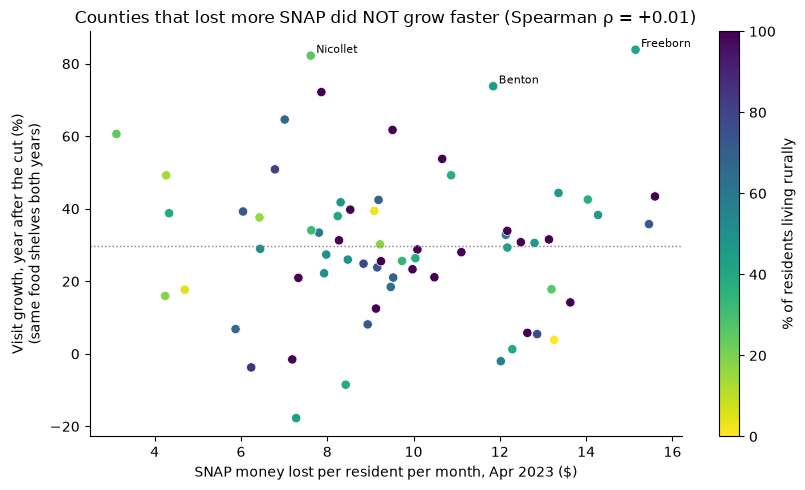

In [13]:
from scipy.stats import spearmanr

rho, p = spearmanr(cc["snap_loss_per_resident"], cc["visit_growth_after_cut"])
rho_x, p_x = spearmanr(cc["snap_loss_per_resident"], cc["extra_growth"])
print(f"loss vs visit growth:        rho = {rho:+.2f} (p = {p:.2f})")
print(f"loss vs EXTRA visit growth:  rho = {rho_x:+.2f} (p = {p_x:.2f})")

fig, ax = plt.subplots(figsize=(8.5, 5))
sc = ax.scatter(cc["snap_loss_per_resident"], cc["visit_growth_after_cut"], c=cc["pct_rural_2020"],
                cmap="viridis_r", s=45, edgecolor="white", linewidth=0.5)
ax.axhline(cc["visit_growth_after_cut"].median(), color="grey", ls=":", lw=1)
for _, r in cc.nlargest(3, "visit_growth_after_cut").iterrows():
    ax.annotate(r["county"], (r["snap_loss_per_resident"], r["visit_growth_after_cut"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("SNAP money lost per resident per month, Apr 2023 ($)")
ax.set_ylabel("Visit growth, year after the cut (%)\n(same food shelves both years)")
ax.set_title(f"Counties that lost more SNAP did NOT grow faster (Spearman ρ = {rho:+.2f})")
plt.colorbar(sc, label="% of residents living rurally")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "q5_c3_county_dose_response.png", dpi=200)
plt.show()

## C4. Same test as groups (easier to read)

- **What:** split counties into three equal groups by how much SNAP they lost, and compare the typical (median) visit growth. Then the same by rural vs. urban.
- **Why:** a group table is easier to explain on a slide than a correlation.

In [14]:
cc["loss_group"] = pd.qcut(cc["snap_loss_per_resident"], 3, labels=["smaller loss", "middle", "bigger loss"])
by_loss = cc.groupby("loss_group", observed=True).agg(
    counties=("county", "size"), median_loss_per_resident=("snap_loss_per_resident", "median"),
    median_visit_growth=("visit_growth_after_cut", "median"), median_extra_growth=("extra_growth", "median")).round(1)
display(by_loss)

cc["area"] = np.where(cc["pct_rural_2020"] >= 50, "more rural (50%+ rural)", "more urban (<50% rural)")
by_area = cc.groupby("area").agg(counties=("county", "size"), median_loss_per_resident=("snap_loss_per_resident", "median"),
                                 median_visit_growth=("visit_growth_after_cut", "median")).round(1)
display(by_area)

,counties,median_loss_per_resident,median_visit_growth,median_extra_growth
loss_group,,,,
smaller loss,22,6.9,33.7,19.3
middle,22,9.2,25.8,19.1
bigger loss,22,12.8,31.2,18.2


,counties,median_loss_per_resident,median_visit_growth
area,,,
more rural (50%+ rural),38,9.2,27.7
more urban (<50% rural),28,9.2,35.8


### Reading Part C

**Counties that lost more SNAP money did *not* see bigger jumps in visits.**
- The correlation is about **0** (no pattern), and the three groups grew about the same: roughly **+26% to +34%**, with about **+18 to +19 points of extra growth** in every group.
- **More urban counties grew a little faster** (median ≈ +36%) than more rural ones (≈ +28%), even though both lost about the same SNAP per resident (≈ $9).

**What this means:**
- The jump after April 2023 was **statewide and fairly even**, not concentrated where SNAP losses were biggest.
- That **weakens** the claim that the cut was *the* cause of the extra growth. A statewide shock that hit everyone similarly (high grocery prices, Q4; the end of other pandemic supports) fits the pattern just as well.
- It **doesn't rule the cut out**: every SNAP household lost money everywhere (at least $95 a month), so food shelf visitors in every county felt it, even if the *per-resident* loss differed. Our county loss measure mostly reflects how many people are on SNAP, not how hard each household was hit.

**Honest bottom line for Q5:** *the timing fits the SNAP cut (Part B), but the county pattern doesn't confirm it (Part C), so we present the cut as a likely contributor alongside other statewide pressures, not the sole cause.*

**Dropped from this test:** the 7 tribal-overlap counties (county SNAP count incomplete), the 5 combined-agency counties (no county SNAP number), Wilkin (no food shelf) and counties with under 1,000 visits in the base year (percent growth too jumpy).

---
# Part D: The answer, the message for lawmakers, and slide-ready material

## D1. Key numbers (computed here so slides always match the notebook)

In [15]:
key = {
    "SNAP benefit per person, Mar 2023 -> Apr 2023 ($/month)":
        f"{state.loc['2023-03-01', 'benefit_per_person']:.0f} -> {state.loc['2023-04-01', 'benefit_per_person']:.0f}",
    "People on SNAP, Mar 2022 -> Mar 2026":
        f"{state.loc['2026-03-01', 'snap_people'] / state.loc['2022-03-01', 'snap_people'] - 1:+.0%}",
    "Food shelf visits, Mar 2022 -> Mar 2026":
        f"{state.loc['2026-03-01', 'visits'] / state.loc['2022-03-01', 'visits'] - 1:+.0%}",
    "Visits YoY growth: before cut / year after cut / year after that (all sites)":
        " / ".join(f"{windows.loc[w, 'visits_yoy']:+.0f}%" for w in windows.index[:3]),
    "Same, same food shelves only (matched sites)":
        " / ".join(f"{robust.loc[w, 'matched sites: visits YoY']:+.0f}%" for w in robust.index[:3]),
    "Counties: SNAP lost per resident vs visit growth (Spearman rho)": f"{rho:+.2f}",
    "Counties: SNAP per 1,000 vs visits per 1,000 (Spearman rho)":
        f"{a2.loc[a2['compared with visits per 1,000'] == 'snap_per_1000', 'Spearman rho'].iloc[0]:+.2f}",
}
pd.Series(key, name="value").to_frame()

,value
"SNAP benefit per person, Mar 2023 -> Apr 2023 ($/month)",260 -> 160
"People on SNAP, Mar 2022 -> Mar 2026",-3%
"Food shelf visits, Mar 2022 -> Mar 2026",+92%
Visits YoY growth: before cut / year after cut / year after that (all sites),+21% / +31% / +8%
"Same, same food shelves only (matched sites)",+11% / +31% / +10%
Counties: SNAP lost per resident vs visit growth (Spearman rho),+0.01
"Counties: SNAP per 1,000 vs visits per 1,000 (Spearman rho)",+0.12


## D2. The answer to Q5, part by part

| Brief asks | Our answer |
|---|---|
| **Do they move together, or does one replace the other?** | **Neither, clearly.** SNAP enrollment stayed flat (Mar 2022 → Mar 2026 ≈ −3%) while food shelf visits rose ≈ 90%, and their month-to-month changes aren't linked. Across counties, more SNAP use goes with only slightly more food shelf use. Food shelf growth came mostly from pressures **beyond SNAP enrollment**. |
| **What happens to food shelf activity when SNAP benefits change?** | When the COVID SNAP boost ended (Apr 2023, ≈ $260 → $160 per person per month), **food shelf visits grew ≈ 10–20 points faster than usual for about a year**, peaking 6–10 months later, even at the same food shelves. **Individuals and pounds did not jump the same way**: more household trips, not more food handed out. The smaller 2025–26 enrollment drop shows at most a small rise (too recent to call). |
| **Does the relationship differ across locations?** | **Not much.** Counties that lost more SNAP per resident did **not** see bigger jumps (rho ≈ 0); growth was similar everywhere (≈ +26% to +34%). More urban counties grew slightly faster than rural ones (≈ +36% vs +28%). |

## D3. The message for lawmakers (one sentence)

> **"When Minnesota's SNAP benefits per person dropped by almost 40% in April 2023, food shelf visits grew much faster than usual for the next year, in every kind of county, even though the number of people on SNAP barely changed. Cutting how much SNAP pays sends households to food shelves that are already at record demand."**

(Say it with the caveat: the timing fits, but other statewide pressures, like grocery prices, rose at the same time, so the cut is one important contributor, not the only cause.)

## D4. What The Food Group can do on Monday

1. **Treat SNAP benefit changes as an early warning.** When a benefit cut is announced, expect food shelf visits to rise **over the following 6–12 months**, and plan supply and donor appeals for that window, not just the first month.
2. **Plan for the increase everywhere, not only high-SNAP counties.** The 2023 jump was statewide and even, so allocation shouldn't assume only high-SNAP areas will feel it.
3. **Watch food per visit.** Visits rose but pounds didn't, so each household likely received less. Pounds per household is a simple indicator to track whether food shelves are keeping up.
4. **Use this in policy arguments:** SNAP benefit **levels** (not only eligibility) matter for food shelf demand.

## D5. Slide-ready charts (in `outputs/q5/`)

| Slide | Chart | One-line takeaway |
|---|---|---|
| 1 | `q5_a1_snap_vs_visits_index.png` | SNAP enrollment stayed flat while food shelf visits kept climbing |
| 2 ⭐ | `q5_b1_visits_yoy.png` | After the SNAP boost ended, visits grew much faster for about a year |
| 3 | `q5_c3_county_dose_response.png` | The jump was similar everywhere, not bigger where SNAP losses were bigger |

**Source note for the slide:** *SNAP: MN Dept. of Human Services, "SNAP and State-Funded Food: Minnesota Cases, Recipients, and Payments", county agency × month, Jan 2022 – Mar 2026, published ≈ 3 weeks after each month. Food shelf: The Food Group (cleaned). Population/poverty: US Census ACS 5-year. Rural share: Census 2020.*

## D6. Limitations (say these before a judge asks)

- **No untouched comparison group:** the April 2023 cut hit all of Minnesota at once, and other things (grocery prices, the end of other pandemic supports) changed around the same time. We show **timing that fits**, not proof of cause.
- **The pre-cut baseline is short** (Jan–Mar 2023, 3 months), because our data starts in 2022.
- **SNAP is reported by county office, not county:** 5 counties share offices and 7 overlap tribal SNAP offices; they're excluded from county comparisons.
- **SNAP data ends March 2026** (publication lag), so the 2025–26 enrollment drop can only be followed for 5 months.
- **Food shelf data counts where the food shelf is**, not where visitors live.